1: Importación de librerías y carga del Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Carga del dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Dataset cargado. Primeras filas:")
display(df.head())

Dataset cargado. Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


2: Análisis Exploratorio (EDA)

Dimensiones: (178, 14)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline   

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


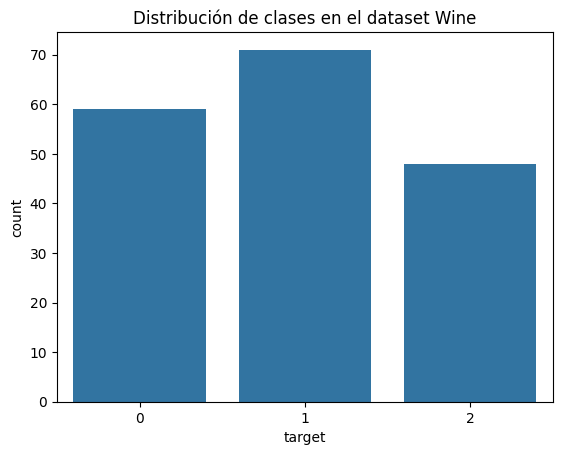

In [2]:
# Dimensiones y tipos
print(f"Dimensiones: {df.shape}")
print("-" * 30)
print(df.info())

# Estadísticas descriptivas
display(df.describe())

# Distribución de clases
sns.countplot(x='target', data=df)
plt.title("Distribución de clases en el dataset Wine")
plt.show()

3: Visualización de datos

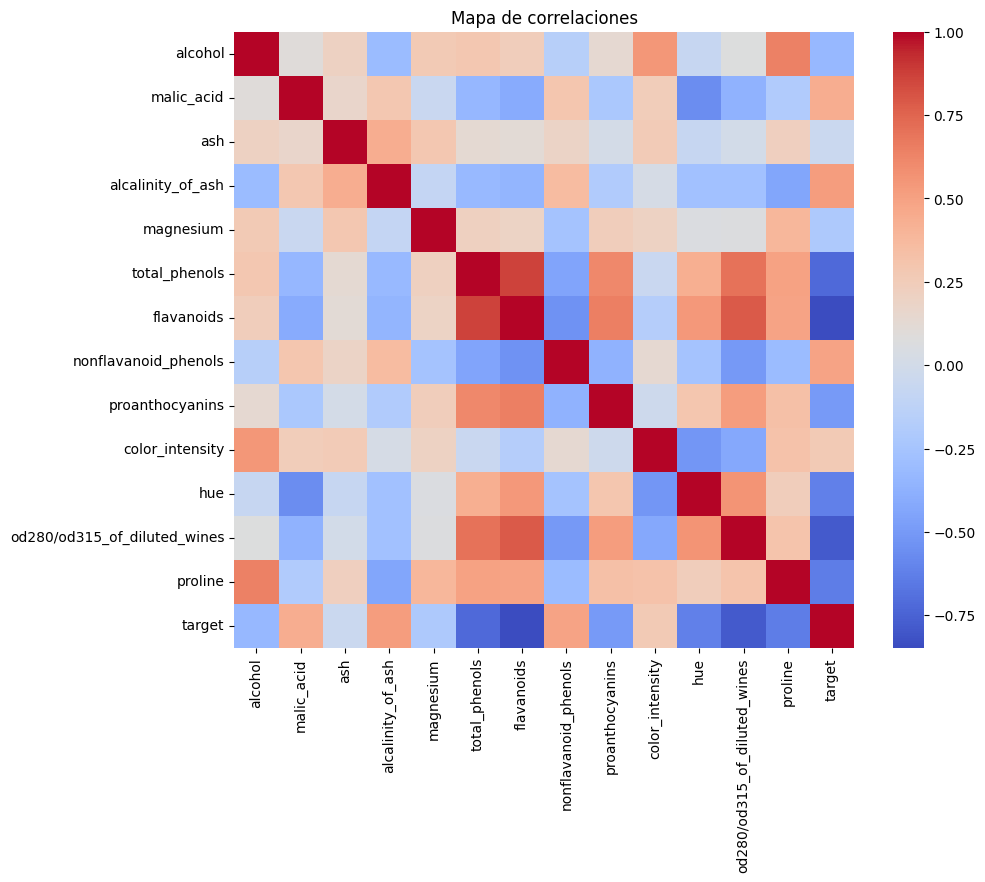

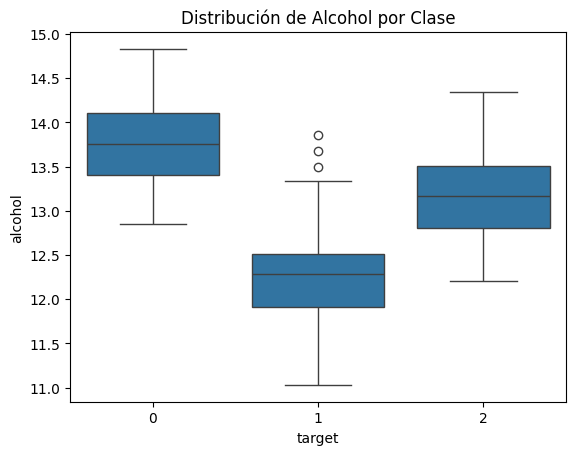

In [3]:
# Mapa de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Mapa de correlaciones")
plt.show()

# Boxplot de una variable predictora vs clase
sns.boxplot(x='target', y='alcohol', data=df)
plt.title("Distribución de Alcohol por Clase")
plt.show()

4: Preparación de datos

In [4]:
X = df.drop('target', axis=1)
y = df['target']

# Separación 70% entrenamiento - 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarización (Media=0, Desviación=1)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Datos preparados y estandarizados.")

Datos preparados y estandarizados.


5: Implementación LDA

In [5]:
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train_s, y_train)
y_pred_lda = lda.predict(X_test_s)

print("Resultados LDA:")
print(classification_report(y_test, y_pred_lda))

Resultados LDA:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



6: Implementación QDA

In [6]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_s, y_train)
y_pred_qda = qda.predict(X_test_s)

print("Resultados QDA:")
print(classification_report(y_test, y_pred_qda))

Resultados QDA:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



7: Visualización de fronteras de decisión (2D)

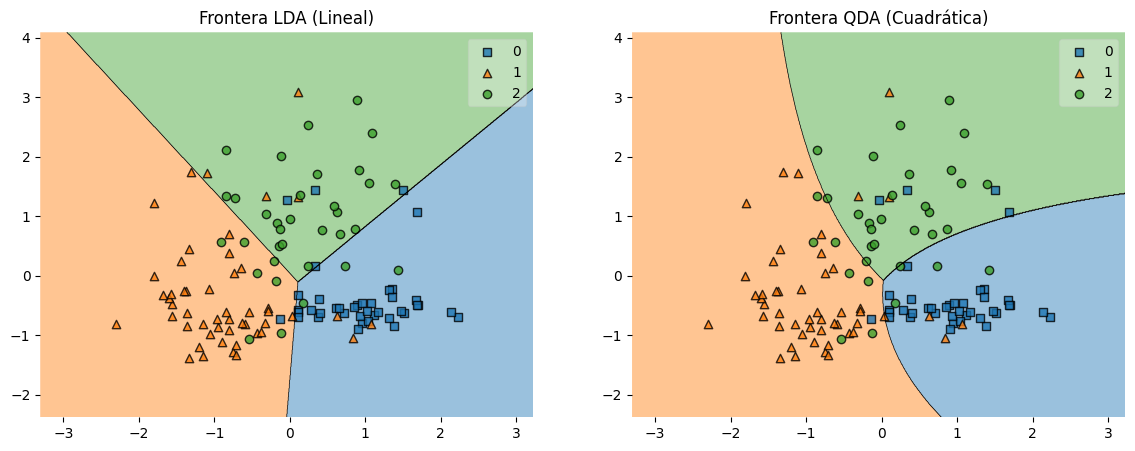

In [7]:
from mlxtend.plotting import plot_decision_regions

# Reducimos a 2 variables para graficar
X_2d = X_train_s[:, [0, 1]]
lda_2d = LinearDiscriminantAnalysis().fit(X_2d, y_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_regions(X_2d, y_train.values, clf=lda_2d, ax=axes[0])
axes[0].set_title("Frontera LDA (Lineal)")

plot_decision_regions(X_2d, y_train.values, clf=qda_2d, ax=axes[1])
axes[1].set_title("Frontera QDA (Cuadrática)")

plt.show()